## ME471:Finite Element Method (2024 Spring)
# HW5 : Mar.19th
Li Zheng 
### Problem 2: Additional topics about truss structures (30 pts)
Using numpy or sympy (without OpenseesPy), solve problem 3.50, 3.53, and 3.58 of the textbook. Submit the solution as jupter notebooks with markdowns.

### a) 3.53
Derive the stiffness matrix for the nonprismatic bar shown in Figure P3-53 using the principle of minimum potnetial energy. Let E be constant.
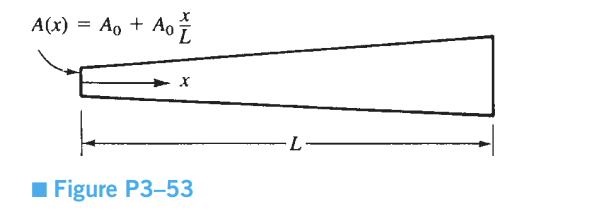

In the problem, we first set shape function,. Stiffness matrix is the integrate of EA and B, which is calucalted below.

In [86]:
import sympy
A0,E,L = sympy.symbols('A0 E L')
x = sympy.symbols('x')
d = sympy.Matrix(sympy.symbols("u:2", real=True))

# cross-sectional area
A = A0 + A0 * x / L

# shape functions
# matrix array of shape functions
N = sympy.Matrix(sympy.symbols("N:2", real=True)).T
N[0] = x/L
N[1] = 1-x/L

B = N.diff(x)
D = sympy.Matrix([[E]])

# integrate from x=0 to x=L
Ke = sympy.integrate(A * B.T @ D @ B, (x,0,L))
Ke

Matrix([
[ 3*A0*E/(2*L), -3*A0*E/(2*L)],
[-3*A0*E/(2*L),  3*A0*E/(2*L)]])

### c) 3.58
Determine the energy equivalent nodal forces for the axial distributed loading shown acting on the bar elements in Figure P3-58
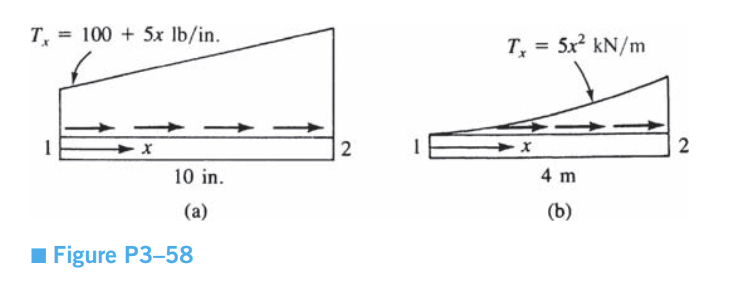

### Problem3: Weighted residual methods (20 pts)
Solve Problem 3.60 of the textbook. Submit the solution as jupyter notebooks with markdowns. For collocation method and subdomain method, select points and subdomains by the approach described in Section 3.13. Hint: You can use sympy to simplify the problem.
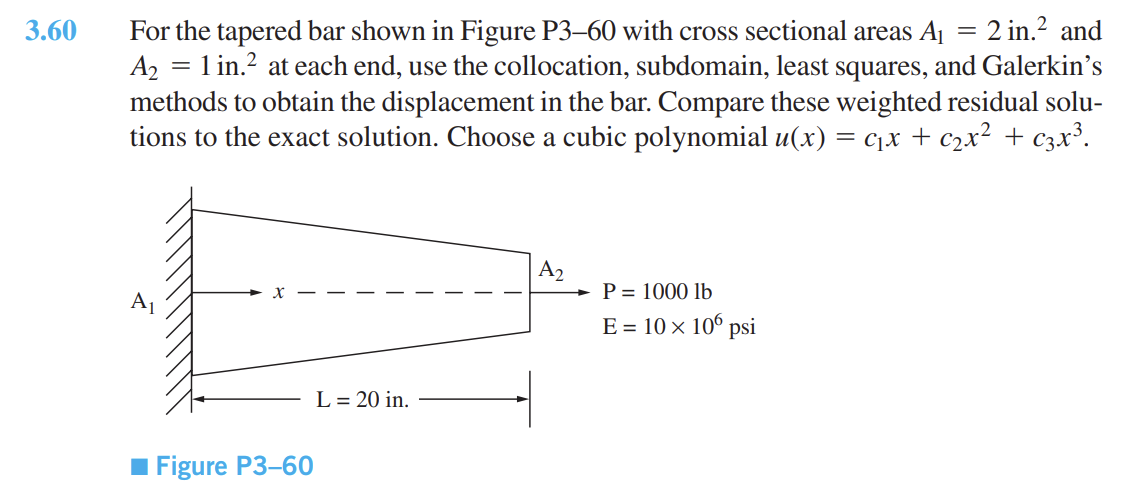

In the problem, we first define the crossectional area function, shhape functionn, and load funtion first.

In [304]:
import sympy
A1,A2,E,x,L = sympy.symbols('A1 A2 E x L')
P = 1000

# cross-sectional area
A = A1 + (A2-A1) * x / L

# shape functions
N = sympy.Matrix(sympy.symbols("N:3", real=True)).T
N[0] = x
N[1] = x**2
N[2] = x**3

# coefficients
c = sympy.Matrix(sympy.symbols("c:3", real=True))

u_hat = N.dot(c)
u_hat

c0*x + c1*x**2 + c2*x**3

### a) Collocation method

Collocation method determinate the coefficients by making residual values at x = 0, x = L/3, x = 2L/3 equals to zero.

In [305]:
# Residual
R = A * E * u_hat.diff(x) - P  # u_hat.diff(x)= du/dx
Rc = R.subs({A1:2.0,A2:1.0,L:20.0,E:10**7})
Length = 20.0 # in
eq1 = Rc.subs(x, 0)
eq2 = Rc.subs(x, Length/3) 
eq3 = Rc.subs(x, 2*Length/3) 
c_coeff = sympy.solve((eq1,eq2,eq3))
print (c_coeff)
c_values = [c_coeff[c[0]], c_coeff[c[1]], c_coeff[c[2]]]
uc = c_coeff[c[0]] * N[0] + c_coeff[c[1]] * N[1] + c_coeff[c[2]] * N[2]
uc

{c0: 5.00000000000000e-5, c1: 5.62500000000002e-7, c2: 1.87499999999999e-8}


1.87499999999999e-8*x**3 + 5.62500000000002e-7*x**2 + 5.0e-5*x

### b) Subdomain method

Subdomain method seperate the residual function into three equal parts, and the integrates of each part equal to zero.

In [306]:
# Residual
R = A * E * u_hat.diff(x) - P  # u_hat.diff(x)= du/dx
Rs = R.subs({A1:2.0,A2:1.0,L:20.0,E:10**7})
Length = 20.0 #in
eq1 = sympy.integrate(Rs,(x,0,Length/3))
eq2 = sympy.integrate(Rs,(x,Length/3,2*Length/3))
eq3 = sympy.integrate(Rs,(x,2*Length/3,Length))
c_coeff = sympy.solve((eq1,eq2,eq3))
print (c_coeff)
c_values = [c_coeff[c[0]], c_coeff[c[1]], c_coeff[c[2]]]
us = c_coeff[c[0]] * N[0] + c_coeff[c[1]] * N[1] + c_coeff[c[2]] * N[2]
us

{c0: 5.08771929824563e-5, c1: 3.94736842105246e-7, c2: 2.63157894736847e-8}


2.63157894736847e-8*x**3 + 3.94736842105246e-7*x**2 + 5.08771929824563e-5*x

### c) Least squares method

Least squares method uses the integrate of residual function multipied with differential residual function by coefficients. And the integrate results all equal to zero.

In [309]:
# Residual
R = A * E * u_hat.diff(x) - P  # u_hat.diff(x)= du/dx
Rl = R.subs({A1:2.0,A2:1.0,L:20.0,E:10**7})
Length = 20.0 #in
eq1 = sympy.diff(Rl,c[0])
eq2 = sympy.diff(Rl,c[1])
eq3 = sympy.diff(Rl,c[2])
Eq1 = sympy.integrate(Rl*eq1,(x,0,Length))
Eq2 = sympy.integrate(Rl*eq2,(x,0,Length))
Eq3 = sympy.integrate(Rl*eq3,(x,0,Length))
c_coeff = sympy.solve((Eq1, Eq2, Eq3),c)
print (c_coeff)
c_values = [c_coeff[c[0]], c_coeff[c[1]], c_coeff[c[2]]]
ul = c_coeff[c[0]] * N[0] + c_coeff[c[1]] * N[1] + c_coeff[c[2]] * N[2]
ul

{c0: 5.06700167504189e-5, c1: 4.18760469011688e-7, c2: 2.56490787269695e-8}


2.56490787269695e-8*x**3 + 4.18760469011688e-7*x**2 + 5.06700167504189e-5*x

### d) Galerkin's method

Galerkin's method use the integrate of residual function multiplied by the shape function N[0]. Each of the integrate results all equal zero.

In [314]:
# Weighted residual
R = A * E * u_hat.diff(x) - P  # u_hat.diff(x)= du/dx
Length = 20.0 #in
Rg = R.subs({A1:2.0,A2:1.0,L:20.0,E:10**7})
rw1 = sympy.integrate(Rg*N[0], (x,0,Length))
rw2 = sympy.integrate(Rg*N[1], (x,0,Length))
rw3 = sympy.integrate(Rg*N[2], (x,0,Length))
c_coeff = sympy.solve((rw1,rw2,rw3))
print (c_coeff)
c_values = [c_coeff[c[0]], c_coeff[c[1]], c_coeff[c[2]]]
ug = c_coeff[c[0]] * N[0] + c_coeff[c[1]] * N[1] + c_coeff[c[2]] * N[2]
ug

{c0: 5.20833333333282e-5, c1: 2.60416666667151e-7, c2: 3.03819444444314e-8}


3.03819444444314e-8*x**3 + 2.60416666667151e-7*x**2 + 5.20833333333282e-5*x

### e) Exact Solution

Since P/AE = du/dx, du = (P/AE)dx, where dx/dA could be replace by L/(A2-A1). Thus, the u = PL/E(A2-A1) * lnA +c. Since at x = 0, the element is fixed to the wall, where the displacment is zero. Using the formual above, we could solve the coefficient c.

In [325]:
u = P*L/E/(A2-A1)*sympy.log(A,sympy.E) + c[0]
eq = u.subs({A1:2.0,A2:1.0,L:20.0,E:10**7})
Eq = sympy.solve(eq.subs(x,0),c[0])
print ('coefficient:',Eq)

coefficient: [0.00138629436111989]


After replacing the c with value, the exact displacement function is well developed.

In [316]:
u_hat = u.subs(c[0],0.00138629436111989)
u_hat = u_hat.subs({A1:2.0,A2:1.0,L:20.0,E:10**7})
u_hat

0.00138629436111989 - 0.002*log(2.0 - 0.05*x)

To compare the approximation accuracy of each method, we first test the predicted displacement of the four approximated models at x = L.

In [324]:
# Absolute Error
ec = (u_hat-uc).subs(x, Length)
es = (u_hat-us).subs(x, Length)
el = (u_hat-ul).subs(x, Length)
eg = (u_hat-ug).subs(x, Length)

fig = plt.figure()

print ('Collocation:',ec)
print ('Subdomain:',es)
print ('Least squares:',el)
print ('Galerkin:',eg)


Method_L = ({1:('Collocation',ec),
          2:('Subdomain',es),
          3:('Least squares',el),
          4:('Galerkin',eg)})

error_min = 5
error_min_index = 0
for i in [1,2,3,4]:
    if abs(Method_L[i][1])< abs(error_min):
        error_min = Method_L[i][1]
        error_min_index = i
print ('The best approximation method consider the value at x = L is',Method_L[error_min_index][0],'Method')

Collocation: 1.12943611198903e-5
Subdomain: 3.29448839187906e-7
Least squares: 1.97208691079864e-7
Galerkin: -2.59452776898552e-6
The best approximation method consider the value at x = L is Least squares Method


<Figure size 640x480 with 0 Axes>

Another method to compare the approximation accuracy of each method is to evaluate the variance of the error. 200 points are selected uniformly as samples.

In [322]:
import numpy as np
import matplotlib.pyplot as plt
x_plot = np.linspace(0,20,200)
uc_plot = 1.87499999999999*10**(-8)*x_plot**3+5.62500000000002*10**(-7)*x_plot**2+5.0*10**(-5)*x_plot
us_plot = 2.63157894736847*10**(-8)*x_plot**3+3.94736842105246*10**(-7)*x_plot**2+5.08771929824563*10**(-5)*x_plot
ul_plot = 2.56490787269695*10**(-8)*x_plot**3+4.18760469011688*10**(-7)*x_plot**2+5.06700167504189*10**(-5)*x_plot
ug_plot = 3.03819444444314*10**(-8)*x_plot**3+2.60416666667151*10**(-7)*x_plot**2+5.20833333333282*10**(-5)*x_plot
u_hat_plot = 0.00138629436111989- 0.002*np.log(2.0-0.05*x_plot)


print ('Collocation:',np.var(uc_plot-u_hat_plot))
print ('Subdomain:',np.var(us_plot-u_hat_plot))
print ('Least squares:',np.var(ul_plot-u_hat_plot))
print ('Galerkin:',np.var(ug_plot-u_hat_plot))


Method_v = ({1:('Collocation',np.var(uc_plot-u_hat_plot)),
          2:('Subdomain',np.var(us_plot-u_hat_plot)),
          3:('Least squares',np.var(ul_plot-u_hat_plot)),
          4:('Galerkin',np.var(ug_plot-u_hat_plot))})

var_min = 5
var_min_index = 0
for i in [1,2,3,4]:
    if abs(Method_v[i][1])< abs(error_min):
        var_min = Method_v[i][1]
        var_min_index = i
print ('The best approximation method considering the variance is',Method_v[var_min_index][0],'Method')

Collocation: 5.221016485988597e-12
Subdomain: 5.435078984167966e-13
Least squares: 7.820255259322537e-13
Galerkin: 6.253523777615944e-13
The best approximation method considering the variance is Galerkin Method


Also, we could compare the approxiamtion accuracy using graphs.

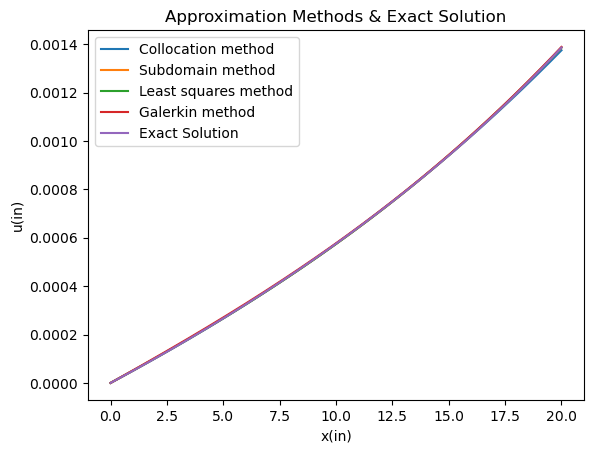

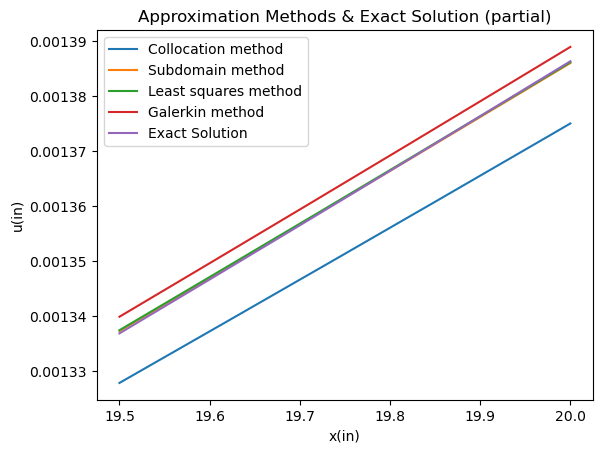

In [2]:
import numpy as np
import matplotlib.pyplot as plt
x_plot = np.linspace(0,20,200)
uc_plot = 1.87499999999999*10**(-8)*x_plot**3+5.62500000000002*10**(-7)*x_plot**2+5.0*10**(-5)*x_plot
us_plot = 2.63157894736847*10**(-8)*x_plot**3+3.94736842105246*10**(-7)*x_plot**2+5.08771929824563*10**(-5)*x_plot
ul_plot = 2.56490787269695*10**(-8)*x_plot**3+4.18760469011688*10**(-7)*x_plot**2+5.06700167504189*10**(-5)*x_plot
ug_plot = 3.03819444444314*10**(-8)*x_plot**3+2.60416666667151*10**(-7)*x_plot**2+5.20833333333282*10**(-5)*x_plot
u_hat_plot = 0.00138629436111989- 0.002*np.log(2.0-0.05*x_plot)
#print (uc_plot)

# 绘制图形
plt.plot(x_plot,uc_plot, label='Collocation method')
plt.plot(x_plot,us_plot, label='Subdomain method')
plt.plot(x_plot,ul_plot, label='Least squares method')
plt.plot(x_plot,ug_plot, label='Galerkin method')
plt.plot(x_plot,u_hat_plot, label='Exact Solution')

# 添加标题和图例
plt.title('Approximation Methods & Exact Solution')
plt.xlabel('x(in)')
plt.ylabel('u(in)')
plt.legend()

# 显示图形
plt.show()

x_plot = np.linspace(19.5,20,200)
uc_plot = 1.87499999999999*10**(-8)*x_plot**3+5.62500000000002*10**(-7)*x_plot**2+5.0*10**(-5)*x_plot
us_plot = 2.63157894736847*10**(-8)*x_plot**3+3.94736842105246*10**(-7)*x_plot**2+5.08771929824563*10**(-5)*x_plot
ul_plot = 2.56490787269695*10**(-8)*x_plot**3+4.18760469011688*10**(-7)*x_plot**2+5.06700167504189*10**(-5)*x_plot
ug_plot = 3.03819444444314*10**(-8)*x_plot**3+2.60416666667151*10**(-7)*x_plot**2+5.20833333333282*10**(-5)*x_plot
u_hat_plot = 0.00138629436111989- 0.002*np.log(2.0-0.05*x_plot)
#print (uc_plot)

# 绘制图形
plt.plot(x_plot,uc_plot, label='Collocation method')
plt.plot(x_plot,us_plot, label='Subdomain method')
plt.plot(x_plot,ul_plot, label='Least squares method')
plt.plot(x_plot,ug_plot, label='Galerkin method')
plt.plot(x_plot,u_hat_plot, label='Exact Solution')

# 添加标题和图例
plt.title('Approximation Methods & Exact Solution (partial)')
plt.xlabel('x(in)')
plt.ylabel('u(in)')
plt.legend()

# 显示图形
plt.show()